## Polynomial Regression

Polynomial Regression is a regression technique used when the relationship between input features and output is **non-linear**.

Instead of fitting a straight line, it fits a **curve** to the data.

---

### Problem with Linear Regression

Linear Regression works well only when:
- data follows a straight-line relationship.

But many real-world datasets contain:
- curved/non-linear patterns.

In such cases:
- a straight line cannot fit the data properly.

---

### Main Idea

Polynomial Regression adds higher-degree features like:

$$
x^2,\ x^3,\ x^4
$$

to capture curved relationships.

Instead of:

$$
y = mx + b
$$

we use:

$$
y = b_0 + b_1x + b_2x^2 + b_3x^3
$$

---

### Important Intuition

Even though the graph becomes curved:

> Polynomial Regression is still mathematically a Linear Model,

because the coefficients remain linear.

---

### Underfitting vs Overfitting

#### Underfitting
- Degree is too low
- Model cannot capture the pattern

#### Overfitting
- Degree is too high
- Model starts learning noise

Choosing the correct polynomial degree is very important.

---

### Python Implementation

Polynomial features are created using:

```python
from sklearn.preprocessing import PolynomialFeatures
```

Then standard Linear Regression is applied on transformed features.

---

### Example

Original feature:

$$
x
$$

After transformation (degree = 3):

$$
x,\ x^2,\ x^3
$$

---

### Multivariate Polynomial Regression

For multiple features:

$$
x_1,\ x_2
$$

new polynomial combinations become:

$$
x_1^2,\ x_2^2,\ x_1x_2
$$

---

### Main Intuition

- Linear Regression → fits straight lines
- Polynomial Regression → fits curves using transformed features

In [42]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,SGDRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures  # Our Topic
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [11]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1)

# Equation : y = 0.8x^2 + 0.9x + 2

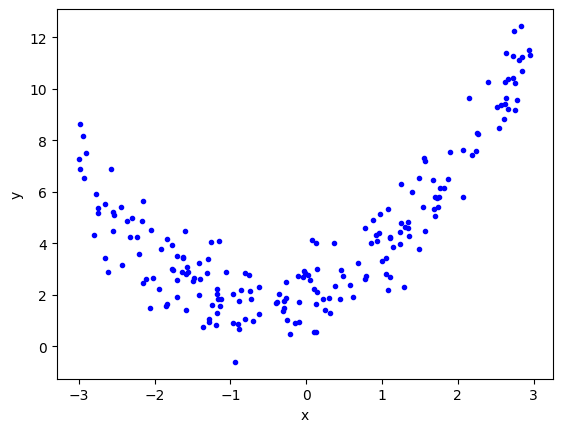

In [12]:
plt.plot(x, y,'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
reg = LinearRegression()

reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = reg.predict(x_test)

r2_score(y_test,y_pred)

0.37166909117795865

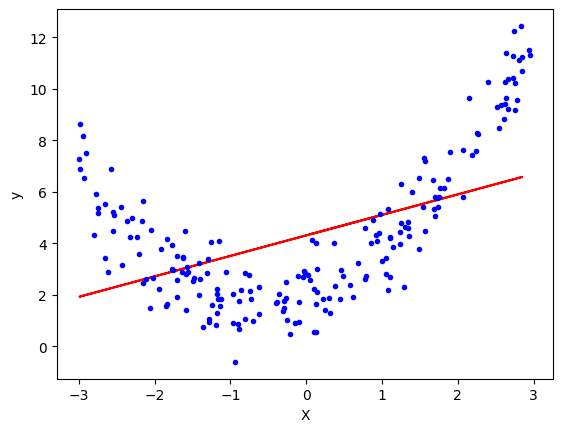

In [18]:
plt.plot(x_train,reg.predict(x_train),color='r')
plt.plot(x, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [19]:
# Underfiting 

Applying Ploynominal Regression

In [25]:
poly = PolynomialFeatures(degree=2,include_bias=True)   # include bias -> b0 term 

In [26]:
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [27]:
print(x_train[0])
print(x_train_trans[0])

[0.97930705]
[1.         0.97930705 0.95904231]


In [28]:
# Now lets train the model using polynominal feature & see the result
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred2 = lr.predict(x_test_trans) 

r2_score(y_test,y_pred2)

0.938178976178124

In [33]:
# It Performs well now (on non-linear / Curve dataset)

In [34]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.87124427 0.80733467]]
[2.05016165]


In [38]:
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
# Creates 200 equally spaced values between -3 and 3
# reshape(200,1) converts it into 2D format because sklearn expects 2D input

x_new_poly = poly.transform(x_new)
# Converts normal input values into polynomial features
# Example:
# x → [x, x², x³ ...] depending on chosen polynomial degree

y_new = lr.predict(x_new_poly)
# Uses the trained Linear Regression model to predict output values
# for the new polynomial-transformed data

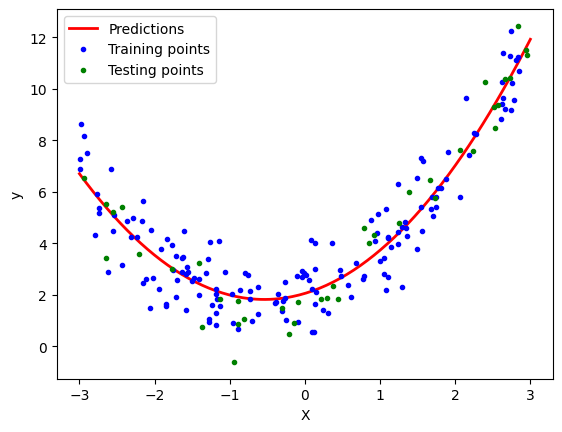

In [39]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [45]:
# Dont see the Code for now just have a Visual for better understanding 
# we have created a function , where we can input no. of degree and see the results

def polynomial_regression(degree):
    x_new=np.linspace(-3, 3, 100).reshape(100, 1)
    x_new_poly = poly.transform(x_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(x, y)
    y_newbig = polynomial_regression.predict(x_new)
    plt.plot(x_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

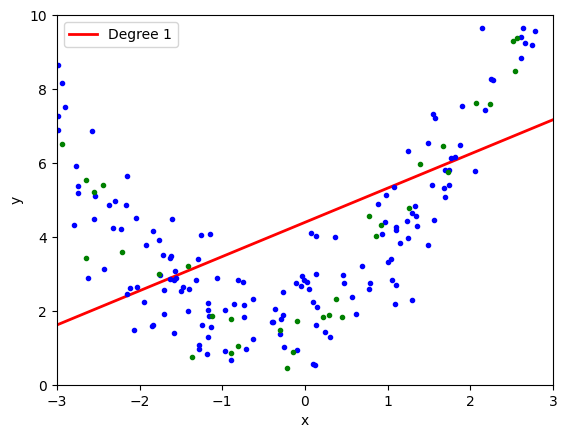

In [50]:
# low degree -> Underfitting

polynomial_regression(1)

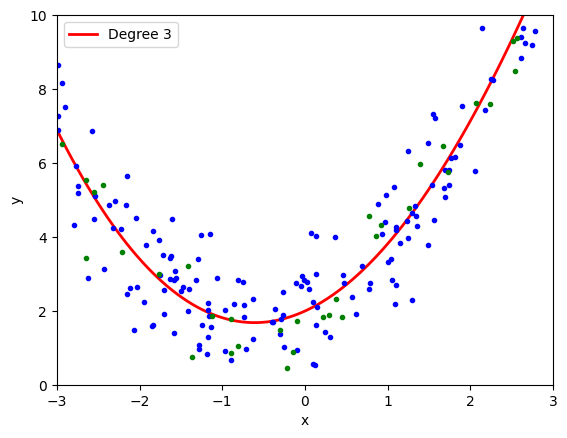

In [54]:
# mild degree -> Optimum

polynomial_regression(3)

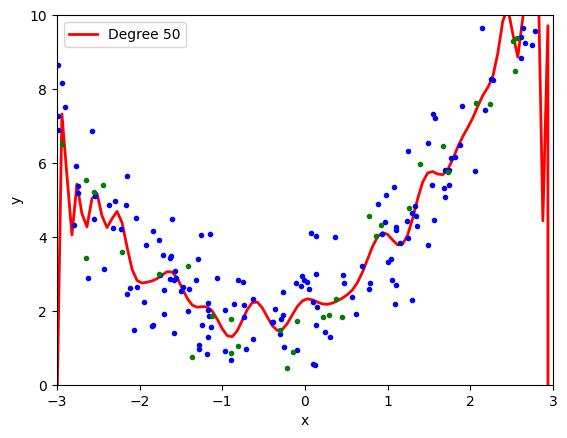

In [57]:
# High degree -> Overfitting

polynomial_regression(50)

In [59]:
# degree
poly.powers_

array([[0],
       [1],
       [2]])

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


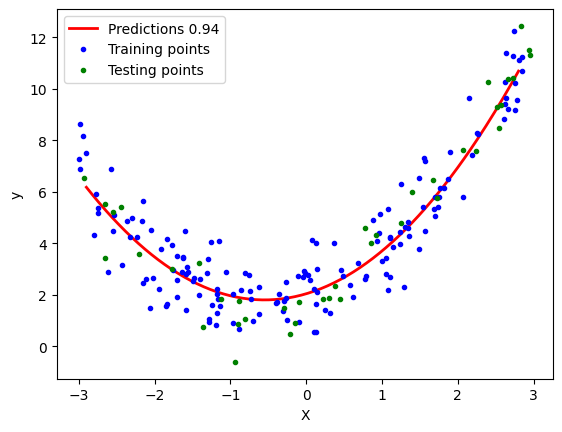

In [61]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(x_train_trans,y_train)

x_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new = sgd.predict(x_new_poly)

y_pred = sgd.predict(x_test_trans)

plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [63]:
# 3D polynomial regression 
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

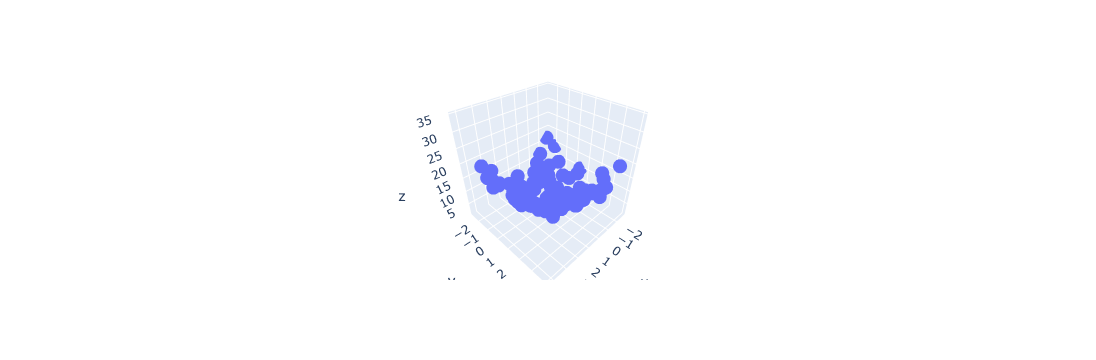

In [64]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [65]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

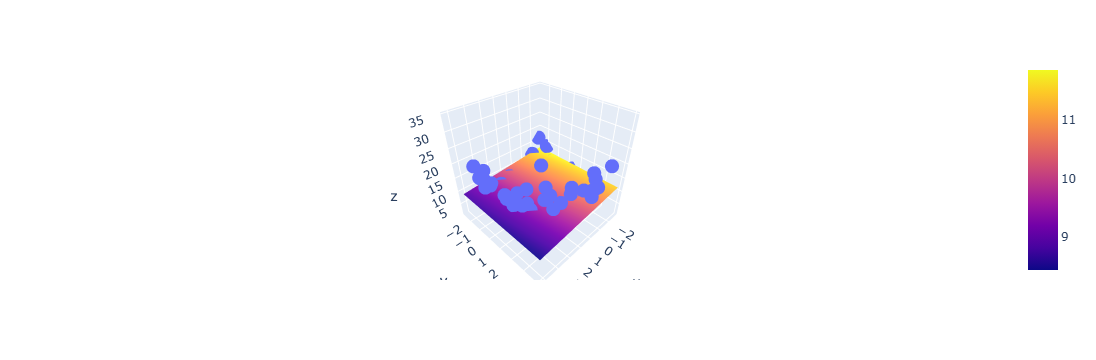

In [67]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show() # underfitting

In [71]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [72]:
poly = PolynomialFeatures(degree=30)
x_multi_trans = poly.fit_transform(x_multi)

In [75]:
print("Input Features :", poly.n_features_in_)
print("Output Features :", poly.n_output_features_)
print("Powers :\n", poly.powers_)

'''
| Attribute            | Meaning                                        |
| -------------------- | ---------------------------------------------- |
| `n_features_in_`     | Number of original input columns               |
| `n_output_features_` | Number of generated polynomial features        |
| `powers_`            | Power combinations used to create new features |
'''

Input Features : 2
Output Features : 496
Powers :
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14

'\n| Attribute            | Meaning                                        |\n| -------------------- | ---------------------------------------------- |\n| `n_features_in_`     | Number of original input columns               |\n| `n_output_features_` | Number of generated polynomial features        |\n| `powers_`            | Power combinations used to create new features |\n'

In [76]:
x_multi_trans.shape

(100, 496)

In [77]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
x_test_multi = poly.transform(final)
z_final = lr.predict(x_multi_trans).reshape(10,10)


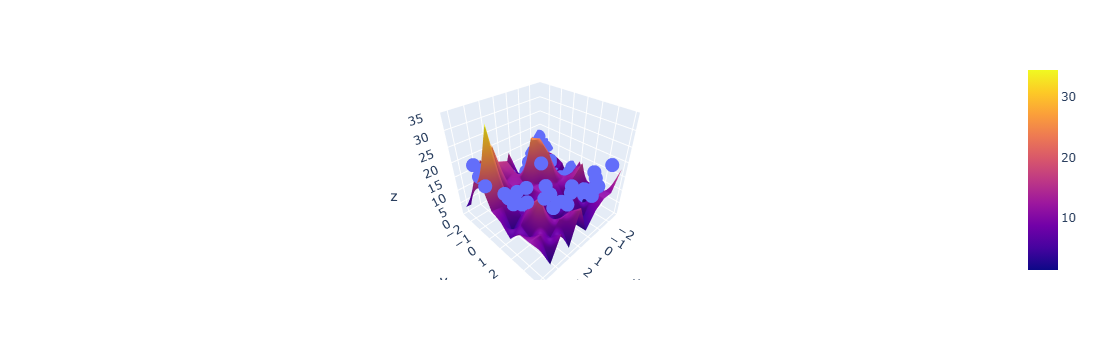

In [80]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()